# Usage in Experiments

## __Result:__ Managing Replicates (Data level)
<img src="../docs/source/_images/result_class_schema.png" width="400em" align="right" style="margin-left: 30px; margin-bottom: 0px; margin-top: -60px;" />

While the `SpheroidCollection` is well suited for managing multiple technical replicates and computing aggregated metrics within a single experimental condition, it does not inherently support structured comparison across repeated experiments or different conditions. To address this, the Result class introduces an additional abstraction layer for organizing and comparing data across multiple conditions and replicates. It builds upon the SpheroidCollection class by assigning collections to specific experimental conditions and replicate groups, thereby enabling systematic comparison at the data level.
A `Result` instance is initialized with a name and one or more named condition dimensions:

In [4]:
from SpheroidPy.experiment import Result
# create new result
my_result = Result("HCT116", condition="cell_number")

Collections are then attached to specific numerical values along those dimensions via the `add_collection()` method.

In [6]:
from SpheroidPy import SpheroidImage, SpheroidSeries, SpheroidCollection
from datetime import datetime

cell_number_dict = {160: ['B5', 'C5'], 800: ['B4', 'C4'], 4000: ['B3', 'C3']}

spheroidcollection_list = []
# iterate over conditions: create 
for cell_number, well_names_list in cell_number_dict.items():
    
    spheroid_collection = SpheroidCollection(name=f'HCT116_{cell_number}_cells')
    
    # iterate over wells
    for well_name in well_names_list:
        spheroid_series = SpheroidSeries(name=f'Well {well_name}')

        for day in range(10,22,2):
            date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
            path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_{well_name}_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
            path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_{well_name}_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
            path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_{well_name}_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

            # create a SpheroidImage and add to SpheroidSeries
            my_spheroid = SpheroidImage(brightfield = path_pc, 
                                        fluorescence_green = path_green, 
                                        fluorescence_red = path_red, 
                                        image_size = (1700,1270))
            spheroid_series.add_spheroid_image(my_spheroid, date_time)

        spheroid_collection.add_spheroid(spheroid_series)
        
    my_result.add_collection(spheroid_collection, condition=cell_number)

The result can again be visualised in an interactive widget, giving a compact overview about the loaded data.

In [8]:
my_result.show()

For the extraction of quantitative information, we again first need to perform segmentation on the loaded images.

In [10]:
my_result.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')])

Result 'HCT116': 100%|██████████| 6/6 [00:17<00:00,  2.91s/it]



Segmentation complete for result 'HCT116':
Successfully segmented 36/36 images across 6 series


Now, we can calculate and compare the growth behaviour over the different cell numbers.

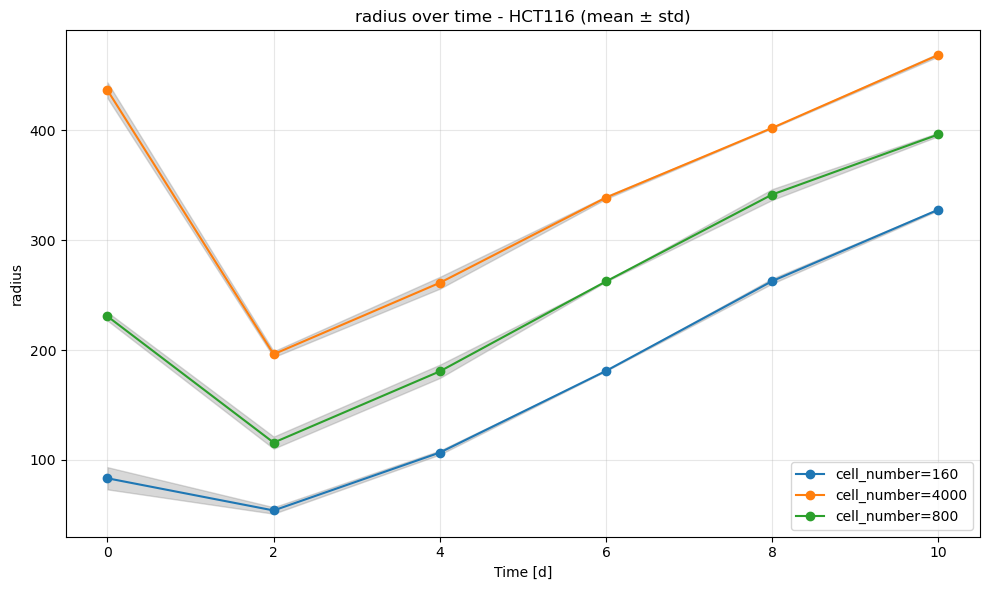

cell_number=160            cell_number=4000           cell_number=800  \
                 mean        std             mean       std            mean   
0.0         83.302324  10.097081       436.636711  7.137236      230.761744   
48.0        54.003899   2.954012       196.262008  2.648868      115.773363   
96.0       106.729407   1.835152       261.314484  5.366859      180.681236   
144.0      181.121739   0.108881       338.923310  1.206068      262.591868   
192.0      262.869491   2.290535       402.355326  0.255703      341.691632   
240.0      327.936139   0.647676       468.821676  1.392960      396.397036   

                 
            std  
0.0    3.823848  
48.0   5.472598  
96.0   6.045326  
144.0  0.272918  
192.0  4.917564  
240.0  1.544154

In [12]:
my_result.metric(plot=True, mean=True)

<br>

## __Experiment:__ Managing Results (Project level)
<img src="../docs/source/_images/experiment_class_schema.png" width="300em" align="right" style="margin-left: 50px; margin-bottom: 0px; margin-top: -70px;" />

The Experiment class represents the highest level of abstraction within the SpheroidPy framework. It groups multiple `Result` objects — typically corresponding to independent experimental runs or biological repetitions of the same protocol — and provides facilities for cross-result metric aggregation, unified segmentation, and full project persistence via hdf5.

In [43]:
from pathlib import Path
from SpheroidPy import Experiment, Result
# create an experiment
spheroid_experiment = Experiment(name='ExperimentName', path=Path('ExperimentData'))

Upon initialization, an hdf5-file is automatically created to store the complete state of the experiment, including associated results, metadata, and analysis outputs. The full state of an experiment can be reloaded at any time:

In [48]:
# load from file
loaded_experiment = Experiment.from_file('ExperimentData/Experiment_ExperimentName.h5')

Loading results: 0result [00:00, ?result/s]


A `Result` object associated with the experiment can be accessed or created (if it does not yet exist) as follows:

In [50]:
result = spheroid_experiment.result('MyResultName')

# Handling of Microwell Plates

In large-scale live-cell imaging experiments, microwell plates often provide the underlying structure for the experimental setup. This is especially common in commercial high-throughput imaging platforms. To support such workflows, seperate `LiveCellReplicate` and `Platemap` classes are introduced for organizing and managing large experimental datasets with microwell-plate-based layouts. While partly losing some of the customizability, this allows for more efficient and clearly structured workflows, enabling direct data transfer from the image dataset to further analysis.

In [52]:
from SpheroidPy.spheroid import SpheroidCollection, SpheroidSeries, SpheroidImage   # import the class
from SpheroidPy.experiment import Result, Experiment, LiveCellReplicate
from pathlib import Path

experiment = Experiment('NewExperiment', path=Path('ExperimentData'))

result_hct116 = experiment.result('HCT116')

Throughout this section, we assume that the Experiment my_experiment and a corresponding Results my_result have already been created, i.e. as described in the previous chapter. A new `LiveCellReplicate` can be created using

In [55]:
replicate1 = result_hct116.replicate('R1', layout=96)

In order to connect this construct with the individual layout of the microwell plate, each `LiveCellReplicate` is associated with one `Platemap`.

A platemap defines the experimental setup for each well, such as cell lines, compound treatments, and its concentrations. To assign a new cell line to the replicate or modify the values of an existing cell line one can use

Output()

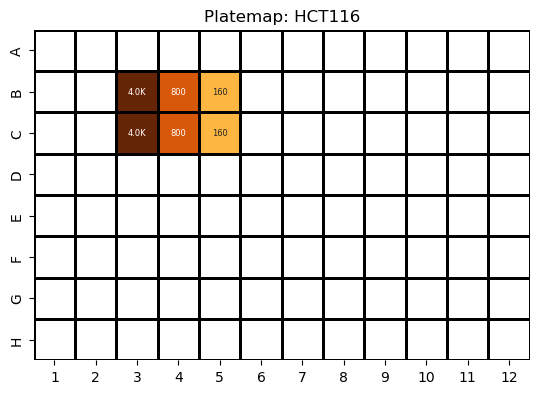

In [58]:
replicate1.platemap.cell_line('HCT116', {'B3:C3':4000, 'B4:C4':800, 'B5:C5':160})

All wells with identical platemap values are interpreted as one experimental condition. These conditions can be listed using:

In [61]:
replicate1.platemap.replicates()

{(('HCT116', 4000),): ['B3', 'C3'],
 (('HCT116', 800),): ['B4', 'C4'],
 (('HCT116', 160),): ['B5', 'C5']}

Once the relevant well positions have been specified, images can be loaded automatically. SpheroidPy therefore searches the selected folder for images that match the naming convention of the specified plate layout. Furthermore, filters can be applied to encounter for different channels.

In [64]:
replicate1.load_images('example_data',['PhaseContrast'],['green'],['red'], image_size=(1700,1270))

Looking for Wells in replicate "R1": ['B3', 'C3', 'B4', 'C4', 'B5', 'C5']


Loading wells for replicate 'R1': 100%|██████████| 6/6 [00:04<00:00,  1.36it/s]

Images have been loaded successfully for replicate "R1"!


Previously introduced operations - such as the `segmentation()`, `metric()` or `show()` methods - remain applicable at the LiveCellReplicate level and are consistently propagated across the hierarchical data structure.

In [66]:
replicate1.show()

.

In [ ]:
replicate1.segmentation(methods=[('ai', 'brightfield'),('thresholding', 'fluorescence_green')], threshold=1.3, confidence=.7, border_margin=7)

Replicate 'R1':   0%|          | 0/6 [00:00<?, ?it/s]